<a href="https://colab.research.google.com/github/halil67/Hause_Predict/blob/main/EnsembleSegmentation_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Ensemble Segmentasyon: Kalp ve Akciğer Haritalama
Bu projede çeşitli modellerin birleşiminden oluşan bir yapay zeka sistemi kullanarak göğüs röntgenlerinden kalp ve akciğer segmentasyonu yapılmaktadır.

**Kullanılan Modeller:** UNet, FPN, DeepLabV3, HTNet-benzeri
**Yöntem:** Ensemble (Soft Voting)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [3]:

import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp


In [4]:
class LungHeartDataset(Dataset):
    def __init__(self, image_dir, mask_root, transform=None):
        self.image_dir = image_dir
        self.mask_dirs = {
            "heart": os.path.join(mask_root, "heart"),
            "left": os.path.join(mask_root, "left_lung"),
            "right": os.path.join(mask_root, "right_lung"),
        }
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        name = os.path.splitext(fname)[0]

        image = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")
        heart = Image.open(os.path.join(self.mask_dirs["heart"], f"{name}.png")).convert("L")
        left = Image.open(os.path.join(self.mask_dirs["left"], f"{name}.png")).convert("L")
        right = Image.open(os.path.join(self.mask_dirs["right"], f"{name}.png")).convert("L")

        # Resize image and masks
        resize = transforms.Resize((224, 224))
        image = resize(image)
        heart = resize(heart)
        left = resize(left)
        right = resize(right)

        # Birleştir: 0 = arka plan, 1 = kalp, 2 = sol akciğer, 3 = sağ akciğer
        mask = np.zeros(np.array(heart).shape, dtype=np.uint8)
        mask[np.array(heart) > 128] = 1
        mask[np.array(left) > 128] = 2
        mask[np.array(right) > 128] = 3

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        mask = torch.from_numpy(mask).long()
        return image, mask



In [5]:

from torchvision.models import resnet18

class HTNetLike(nn.Module):
    def __init__(self, num_classes=4):
        super(HTNetLike, self).__init__()
        self.encoder = resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(self.encoder.children())[:-2])
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, 2), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 2, 2), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, 2), nn.ReLU(),
            nn.ConvTranspose2d(64, num_classes, 2, 2)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [6]:

image_dir = "/content/drive/MyDrive/YZ/hearth/heart_ctr_project/data/wingspan/png"
mask_dir = "/content/drive/MyDrive/YZ/hearth/heart_ctr_project/data/wingspan/mask"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = LungHeartDataset(image_dir, mask_dir, transform=transform)
loader = DataLoader(dataset, batch_size=2, shuffle=True)


In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = smp.Unet("resnet34", classes=4, encoder_weights="imagenet").to(device)
model2 = smp.FPN("resnet34", classes=4, encoder_weights="imagenet").to(device)
model3 = smp.DeepLabV3("resnet34", classes=4, encoder_weights="imagenet").to(device)
model4 = HTNetLike(num_classes=4).to(device)

models = [model1, model2, model3, model4]
for m in models: m.eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 47.6MB/s]


In [13]:
def ensemble_predict(models, x):
    preds = []
    for i, model in enumerate(models):
        with torch.no_grad():
            out = model(x)
            # Resize HTNetLike output to match other models
            if i == 3:  # Assuming HTNetLike is the 4th model in the list
                out = F.interpolate(out, size=(224, 224), mode='bilinear', align_corners=False)
            out = F.softmax(out, dim=1)
            preds.append(out)
    avg = torch.stack(preds).mean(0)
    return avg.argmax(1)

In [26]:

import torch.optim as optim

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total_pixels = 0

    for img, mask in loader:
        img, mask = img.to(device), mask.to(device)

        optimizer.zero_grad()
        out = model(img)  # [B, C, H, W]
        loss = loss_fn(out, mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Tahmin sınıfını al: [B, H, W]
        preds = torch.argmax(out, dim=1)
        correct += (preds == mask).sum().item()
        total_pixels += torch.numel(mask)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total_pixels
    return avg_loss, accuracy


In [27]:

model = model1
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(50):
    loss, acc = train_one_epoch(model, loader, optimizer, loss_fn, device)
    print(f"Epoch {epoch+1}: Loss={loss:.4f} | Accuracy={acc:.4%}")


Epoch 1: Loss=0.0445 | Accuracy=98.2402%
Epoch 2: Loss=0.0408 | Accuracy=98.3871%
Epoch 3: Loss=0.0393 | Accuracy=98.4302%
Epoch 4: Loss=0.0375 | Accuracy=98.4838%
Epoch 5: Loss=0.0381 | Accuracy=98.4822%
Epoch 6: Loss=0.0393 | Accuracy=98.4284%
Epoch 7: Loss=0.0360 | Accuracy=98.5489%
Epoch 8: Loss=0.0326 | Accuracy=98.6905%
Epoch 9: Loss=0.0317 | Accuracy=98.7226%
Epoch 10: Loss=0.0303 | Accuracy=98.7657%
Epoch 11: Loss=0.0295 | Accuracy=98.7873%
Epoch 12: Loss=0.0290 | Accuracy=98.8074%
Epoch 13: Loss=0.0287 | Accuracy=98.8196%
Epoch 14: Loss=0.0263 | Accuracy=98.9220%
Epoch 15: Loss=0.0256 | Accuracy=98.9425%
Epoch 16: Loss=0.0257 | Accuracy=98.9378%
Epoch 17: Loss=0.0254 | Accuracy=98.9590%
Epoch 18: Loss=0.0245 | Accuracy=98.9921%
Epoch 19: Loss=0.0244 | Accuracy=98.9986%
Epoch 20: Loss=0.0247 | Accuracy=98.9847%
Epoch 21: Loss=0.0239 | Accuracy=99.0090%
Epoch 22: Loss=0.0224 | Accuracy=99.0750%
Epoch 23: Loss=0.0225 | Accuracy=99.0743%
Epoch 24: Loss=0.0213 | Accuracy=99.1183%
E

In [28]:

def evaluate_accuracy(models, loader):
    correct, total = 0, 0
    for img, mask in loader:
        img, mask = img.to(device), mask.to(device)
        pred = ensemble_predict(models, img)
        correct += (pred == mask).sum().item()
        total += torch.numel(mask)
    return correct / total

accuracy = evaluate_accuracy(models, loader)
print(f"Ensemble Doğruluk: {accuracy:.4f}")


Ensemble Doğruluk: 0.9392


In [29]:

for i, model in enumerate(models):
    torch.save(model.state_dict(), f"model_{i+1}.pt")
print("Modeller kaydedildi.")


Modeller kaydedildi.


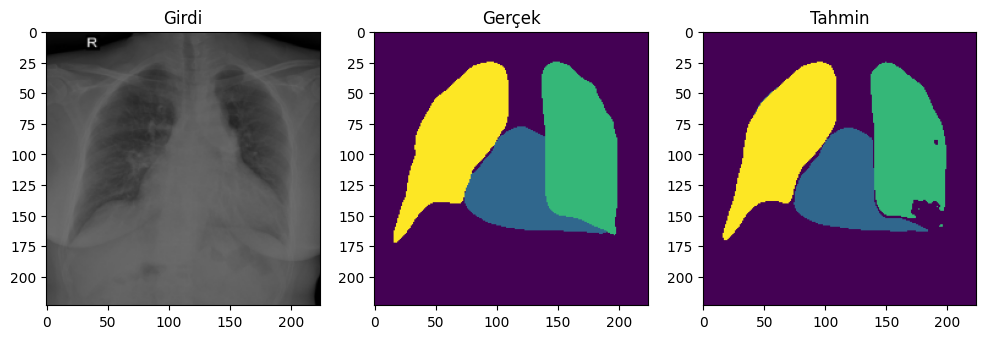

In [30]:

image, mask = next(iter(loader))
image = image.to(device)
pred = ensemble_predict(models, image)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(image[0].permute(1,2,0).cpu()); plt.title("Girdi")
plt.subplot(1,3,2); plt.imshow(mask[0].cpu()); plt.title("Gerçek")
plt.subplot(1,3,3); plt.imshow(pred[0].cpu()); plt.title("Tahmin")
plt.show()


In [48]:
def load_combined_mask(image_name, mask_root):
    fname = os.path.splitext(image_name)[0]

    def load_mask(folder, label_value):
        path = os.path.join(mask_root, folder, fname + ".png")
        if not os.path.exists(path):
            return None
        mask = Image.open(path).convert("L")
        mask_np = np.array(mask)
        # Eğer maske 255 içeriyorsa yeniden etiketle
        mask_np = np.where(mask_np > 0, label_value, 0)
        return mask_np

    heart = load_mask("heart", 1)
    left_lung = load_mask("left_lung", 2)
    right_lung = load_mask("right_lung", 3)

    if heart is None or left_lung is None or right_lung is None:
        return None

    combined = np.maximum.reduce([heart, left_lung, right_lung])
    return combined


In [49]:
def process_image_and_mask(image_path, image_name, mask_root, output_dir):
    fname = os.path.splitext(image_name)[0]
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image) / 255.0

    mask_array = load_combined_mask(image_name, mask_root)
    mask = torch.tensor(mask_array, dtype=torch.uint8)

    heart_mask = (mask == 1)
    heart_box = get_bounding_box(heart_mask)
    if not heart_box:
        print(f"Skipping {fname}: Heart mask missing")
        return None

    heart_left = heart_box[0][1].item()
    heart_right = heart_box[1][1].item()
    mid_x = mask.shape[1] // 2

    # A ve B ölçümü
    A = max(0, mid_x - heart_left)
    B = max(0, heart_right - mid_x)

    # Akciğerlerin alt kısmından dış kenarları
    left_bounds = get_lung_bounds_at_bottom(mask, 2)   # left_lung
    right_bounds = get_lung_bounds_at_bottom(mask, 3)  # right_lung
    if not (left_bounds and right_bounds):
        print(f"Skipping {fname}: Lung bounds missing")
        return None

    lung_leftmost = left_bounds[0]
    lung_rightmost = right_bounds[1]
    C = max(1, lung_rightmost - lung_leftmost)

    CTR = round((A + B) / C, 4)

    # Görsel çizim
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np)
    ax.axvline(x=mid_x, color='cyan', label='Spinal line')
    ax.axvline(x=heart_left, color='red', linestyle='--', label='Heart Left')
    ax.axvline(x=heart_right, color='red', linestyle='--', label='Heart Right')
    ax.axvline(x=lung_leftmost, color='green', linestyle=':', label='Lung Outer Left')
    ax.axvline(x=lung_rightmost, color='green', linestyle=':', label='Lung Outer Right')
    ax.set_title(f"{fname} | CTR = {CTR:.2f}")
    ax.axis("off")
    ax.legend()

    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"{fname}_ctr.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    return {
        "filename": fname,
        "A": A,
        "B": B,
        "C": C,
        "HeartLeft": heart_left,
        "HeartRight": heart_right,
        "LungLeftOuter": lung_leftmost,
        "LungRightOuter": lung_rightmost,
        "CTR": CTR
    }

def get_lung_bounds_at_bottom(mask_tensor, label_id, lines_from_bottom=15):
    """
    Akciğer maskesinin en alt 15 satırında en sol ve sağ kenarları bulur.
    """
    mask = (mask_tensor == label_id)
    height = mask.shape[0]

    # Eğer görüntü yeterince küçükse, tüm alt kısmı al
    start_row = max(0, height - lines_from_bottom)
    bottom_mask = mask[start_row:, :]

    coords = torch.nonzero(bottom_mask)
    if coords.numel() == 0:
        return None

    x_min = coords[:, 1].min().item()
    x_max = coords[:, 1].max().item()
    return x_min, x_max


In [50]:
input_dir = image_dir           # resimler burada
mask_root = mask_dir              # yeni mask yapısı
output_dir = image_dir+"/output"           # sonuçlar buraya

results = []

for image_name in os.listdir(input_dir):
    if image_name.endswith(".png"):
        image_path = os.path.join(input_dir, image_name)
        try:
            result = process_image_and_mask(image_path, image_name, mask_root, output_dir)
            if result:
                results.append(result)
        except Exception as e:
            print(f"{image_name} atlandı: {e}")

# Sonuçları CSV'ye kaydet
pd.DataFrame(results).to_csv(os.path.join(output_dir, "ctr_results.csv"), index=False)


Skipping 1.2.156.112536.2.560.224076136121215.1249741201602.177: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1245885081467.12600: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1245964650788.45245: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1247446095599.1145: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1249217556681.9: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1250332169845.4407: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1250342090390.21921: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1250359772873.52203: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1250623107834.55021: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1251052694112.6081: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.1251124539681.19539: Lung bounds missing
Skipping 1.2.156.112536.2.560.224076136121215.125131